In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.datasets import load_iris
from mpl_toolkits.mplot3d import Axes3D

In [27]:
#load dataset
iris = load_iris()
data = pd.DataFrame(iris.data, columns = iris.feature_names)
data['target'] = iris.target
data

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


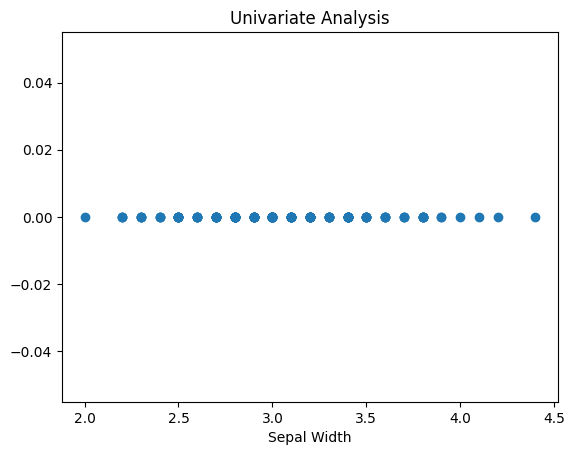

In [28]:
#univariate analysis
plt.scatter(data['sepal width (cm)'], np.zeros_like(data['sepal width (cm)']))
plt.xlabel('Sepal Width')
plt.title('Univariate Analysis')
plt.show()

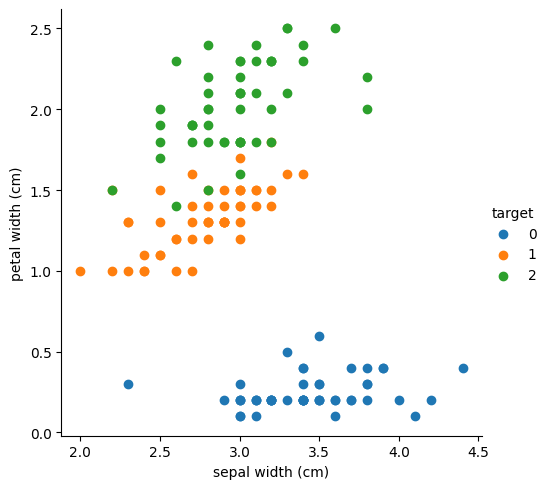

In [29]:
#bivariate analysis
sns.FacetGrid(data, hue='target', height=5).map(plt.scatter,'sepal width (cm)','petal width (cm)').add_legend()

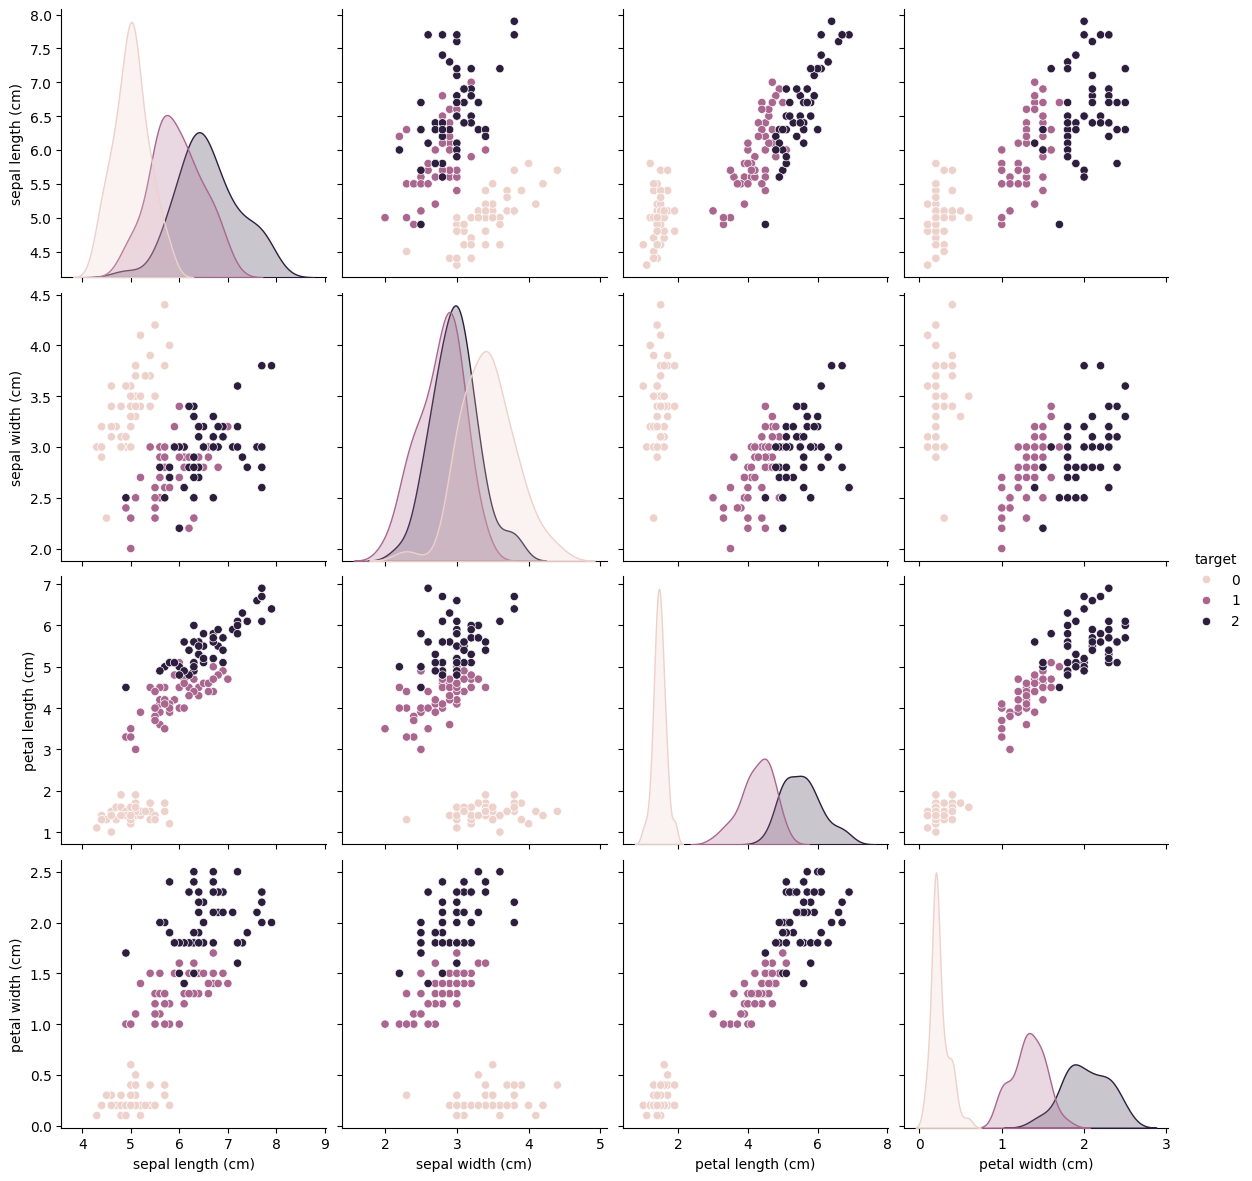

In [30]:
#multivariate analysis
sns.pairplot(data,hue='target',height=3)

In [31]:
#prepare dependent variable
y = data['sepal length (cm)']

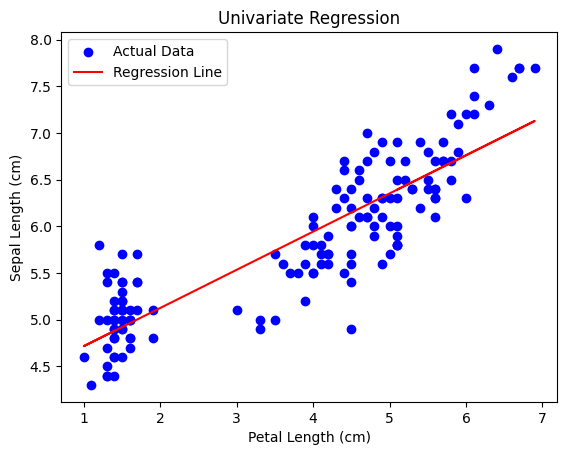

In [32]:
#univariate linear regression
X_uni = data[['petal length (cm)']]

model_uni = LinearRegression()
model_uni.fit(X_uni, y)

y_pred_uni = model_uni.predict(X_uni)
r2_uni = r2_score(y, y_pred_uni)

# Plot Univariate Regression
plt.figure()
plt.scatter(X_uni, y, color='blue', label='Actual Data')
plt.plot(X_uni, y_pred_uni, color='red', label='Regression Line')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Sepal Length (cm)')
plt.title('Univariate Regression')
plt.legend()
plt.show()

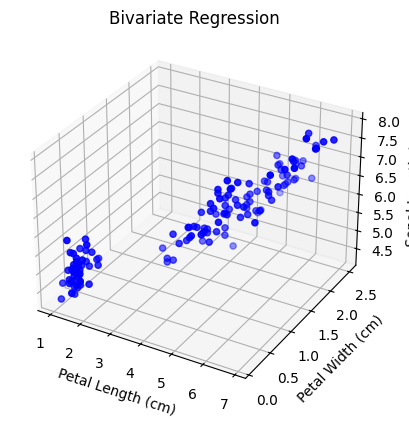

In [33]:
#bivariate linear regression
X_bi = data[['petal length (cm)', 'petal width (cm)']]

model_bi = LinearRegression()
model_bi.fit(X_bi, y)

y_pred_bi = model_bi.predict(X_bi)
r2_bi = r2_score(y, y_pred_bi)

# Plot Bivariate Regression (3D)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_bi.iloc[:, 0], X_bi.iloc[:, 1], y, color='blue')

ax.set_xlabel('Petal Length (cm)')
ax.set_ylabel('Petal Width (cm)')
ax.set_zlabel('Sepal Length (cm)')
ax.set_title('Bivariate Regression')
plt.show()

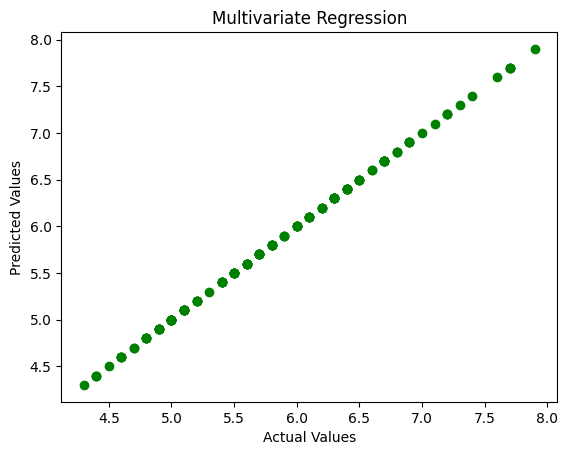

In [34]:
#Multivariate Regression
X_multi = data.drop(columns=['target'])

model_multi = LinearRegression()
model_multi.fit(X_multi, y)

y_pred_multi = model_multi.predict(X_multi)
r2_multi = r2_score(y, y_pred_multi)

# Plot Multivariate Regression (Predicted vs Actual)
plt.figure()
plt.scatter(y, y_pred_multi, color='green')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Multivariate Regression')
plt.show()

In [35]:
#Results
print("UNIVARIATE REGRESSION")
print("Coefficient:", model_uni.coef_)
print("Intercept:", model_uni.intercept_)
print("R-squared:", r2_uni)

print("\nBIVARIATE REGRESSION")
print("Coefficients:", model_bi.coef_)
print("Intercept:", model_bi.intercept_)
print("R-squared:", r2_bi)

print("\nMULTIVARIATE REGRESSION")
print("Coefficients:", model_multi.coef_)
print("Intercept:", model_multi.intercept_)
print("R-squared:", r2_multi)


UNIVARIATE REGRESSION
Coefficient: [0.40892228]
Intercept: 4.306603415047579
R-squared: 0.759954645772515

BIVARIATE REGRESSION
Coefficients: [ 0.54177715 -0.31955056]
Intercept: 4.190582428651586
R-squared: 0.7662612975425306

MULTIVARIATE REGRESSION
Coefficients: [ 1.00000000e+00  2.22638574e-16 -1.01586076e-16 -2.32824196e-16]
Intercept: -4.440892098500626e-15
R-squared: 1.0
